# 🌊 Shoreline Extraction API: Prediction Tutorial

⚠️ **PREREQUISITE:** Before running the cells below, please ensure that your Docker container is up and running, and that the API is accessible (by default at `http://localhost:5000`).

This notebook focuses specifically on the **Prediction** capabilities of the SOCIB Shoreline Extraction API. 
Based on the API's `PredictArgsSchema`, we can control the extraction process by specifying whether the input image is rectified, and optionally applying a Region of Interest (ROI) crop before processing.

In this tutorial, we will use `OpenCV` to load an image, encode it into bytes, and use the `requests` library to send a fully parameterized `POST` request to the `/predict/` endpoint.

In [16]:
import cv2
import requests
import json
from IPython.display import Image, display 

# --- 1. API Endpoint Configuration ---
base_url = "http://localhost:5000" # Important: Update this to your actual API base URL if different
endpoint = "/v2/models/socib_shoreline_extraction/predict/"
API_URL = base_url + endpoint

# Path to your local test image (.jpg, .jpeg, or .png)
MEDIA_PATH = "<path_to_your_image.jpg>"

print(f"Target URL: {API_URL}")

Target URL: http://localhost:5000/v2/models/socib_shoreline_extraction/predict/


## ⚙️ Configuring the Request Payload and Headers

According to the API schema, parameters are divided into:
1. **Headers**: The `accept` header to define the response format (`application/json` or `image/*`).
2. **Files**: The raw image data (`location="form"`, field name: `file`).
3. **Form/Query Data**: The extraction parameters (`rectified`, `boolean_crop_roi`, `crop_roi`).

Let's configure them for our request.

In [13]:
# --- 2. Define Headers ---
headers = {
    # "accept": "application/json"  # Uncomment if you want raw extraction coordinates
    "accept": "image/png"           # Requesting the processed image with the extracted shoreline
}

# --- 3. Define Inference Parameters ---
# These map exactly to the Marshmallow PredictArgsSchema provided.
payload = {
    "rectified": True,          # "true" for planimetric top-down view, "false" for oblique camera perspective.
    
    "boolean_crop_roi": False,  # Set to "true" to enable cropping before extraction.
    
    "crop_roi": [640, 480, 1000, 2000], # Region of Interest [x1, y1, x2, y2]. 
                                        # Sent as a list for standard form-data parsing.

    "accept": "image/*"
}

print("✅ Parameters and headers configured successfully.")

✅ Parameters and headers configured successfully.


## 🚀 Executing the Request with OpenCV

We will read the image using OpenCV, encode it to bytes (JPEG), and send it as a multipart form-data request. Note that the API schema expects the file to be passed under the key name `"file"`.

📤 Sending fully parameterized request to the Shoreline API...
✅ Request successful!



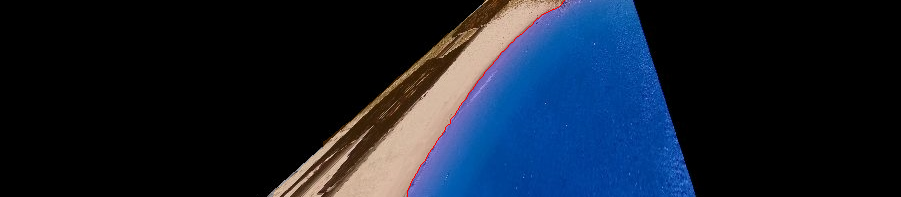

In [ ]:
# --- 4. Read and Encode the Image ---
img = cv2.imread(MEDIA_PATH)

if img is None:
    print(f"❌ Error: Could not load image at '{MEDIA_PATH}'. Please check the path.")
else:
    # Encode the image to JPEG format in memory
    success, encoded_img = cv2.imencode('.jpg', img)

    if not success:
        print("❌ Error: Failed to encode the image.")
    else:
        # Convert the encoded image to raw bytes
        image_bytes = encoded_img.tobytes()
        
        # Prepare the files dictionary. The schema expects the field to be named "file".
        # Format: {"field_name": ("filename", file_bytes, "mime_type")}
        files_payload = {
            "file": ("input_shore.jpg", image_bytes, "image/jpeg")
        }
        
        print("📤 Sending fully parameterized request to the Shoreline API...")
        
        # --- 5. Make the POST Request ---
        response = requests.post(
            API_URL, 
            headers=headers, 
            data=payload, 
            files=files_payload
        )
        
        # --- 6. Handle the Response ---
        if response.status_code == 200:
            print("✅ Request successful!\n")
            
            # If we requested JSON:
            if headers["accept"] == "application/json":
                try:
                    result_json = response.json()
                    print(json.dumps(result_json, indent=4))
                except json.JSONDecodeError:
                    print("Could not parse JSON response.")
            
            elif "image" in headers["accept"]:
                display(Image(data=response.content))
                
        else:
            print(f"❌ Request failed with status code: {response.status_code}")
            print("Response text:", response.text)